# 02 - Exploratory Data Analysis
E-Commerce Sales & Customer Analytics project.

Each section here answers a specific business question rather than just
producing a chart for its own sake — that framing is what turns this
into a Data Analyst project instead of a visualization exercise.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

customers = pd.read_csv('../data/cleaned/customers_clean.csv', parse_dates=['signup_date'])
products = pd.read_csv('../data/cleaned/products_clean.csv')
orders = pd.read_csv('../data/cleaned/orders_clean.csv', parse_dates=['order_date'])
order_items = pd.read_csv('../data/cleaned/order_items_clean.csv')

df = (order_items
      .merge(orders, on='order_id')
      .merge(products, on='product_id')
      .merge(customers, on='customer_id'))

df['gross_revenue'] = df['quantity'] * df['unit_price']
df['net_revenue'] = df['gross_revenue'] * (1 - df['discount'])
df['cost'] = df['quantity'] * df['cost_price']
df['profit'] = df['net_revenue'] - df['cost']

delivered = df[df['status'] == 'Delivered'].copy()
print(f"Analysis table: {len(df):,} line items, {len(delivered):,} from delivered orders")
delivered.head()


Analysis table: 54,068 line items, 30,876 from delivered orders


,order_item_id,order_id,product_id,quantity,unit_price,customer_id,order_date,payment_method,discount,status,...,name,gender,age,city,state,signup_date,gross_revenue,net_revenue,cost,profit
4,17263,7983,396,3,2406.06,2939,2024-11-27,UPI,0.15,Delivered,...,Varenya Lata,Male,17.0,Thiruvananthapuram,Kerala,2024-05-18,7218.18,6135.4530,5423.97,711.4830
5,17262,7983,339,1,8956.93,2939,2024-11-27,UPI,0.15,Delivered,...,Varenya Lata,Male,17.0,Thiruvananthapuram,Kerala,2024-05-18,8956.93,7613.3905,7027.86,585.5305
6,31570,14613,792,3,4093.17,2939,2024-05-26,Debit Card,0.05,Delivered,...,Varenya Lata,Male,17.0,Thiruvananthapuram,Kerala,2024-05-18,12279.51,11665.5345,8665.08,3000.4545
8,41213,19060,442,2,40865.10,2939,2023-02-11,Cash on Delivery,0.20,Delivered,...,Varenya Lata,Male,17.0,Thiruvananthapuram,Kerala,2024-05-18,81730.20,65384.1600,46891.46,18492.7000
9,43649,20188,285,1,7814.13,2939,2023-12-01,UPI,0.05,Delivered,...,Varenya Lata,Male,17.0,Thiruvananthapuram,Kerala,2024-05-18,7814.13,7423.4235,6599.63,823.7935


## Q1: How is revenue changing over time?

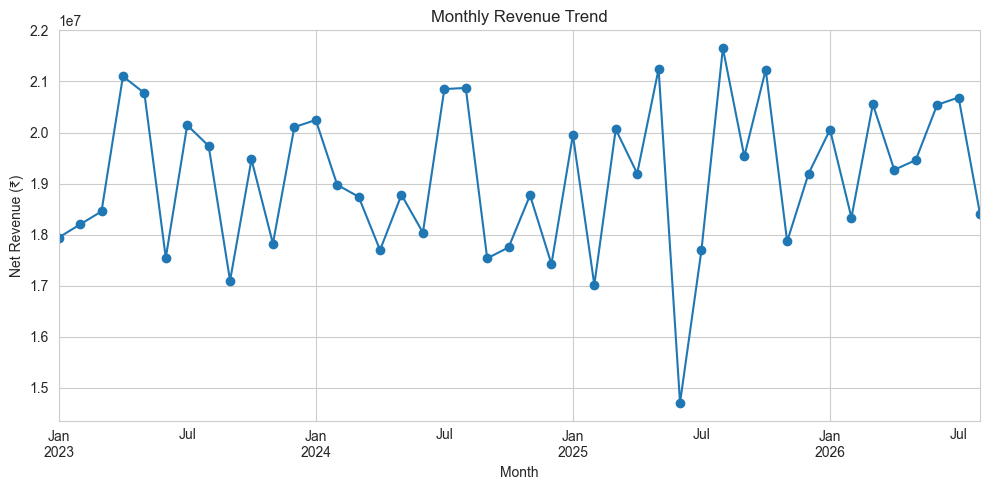

In [14]:
monthly = delivered.set_index('order_date').resample('M')['net_revenue'].sum()

fig, ax = plt.subplots()
monthly.plot(ax=ax, marker='o', linewidth=1.5)
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Net Revenue (₹)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.savefig('../reports/monthly_revenue_trend.png', dpi=120)
plt.show()


## Q2: Which categories generate the most revenue?

C:\Users\Srijon\AppData\Local\Temp\ipykernel_12576\1645389902.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.values, y=cat_revenue.index, ax=ax, palette='viridis')


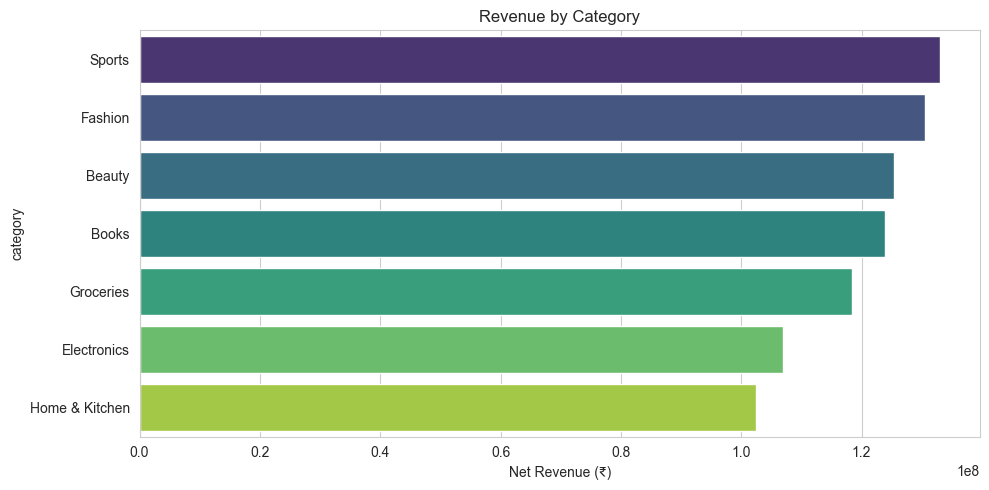

In [15]:
cat_revenue = delivered.groupby('category')['net_revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, ax=ax, palette='viridis')
ax.set_title('Revenue by Category')
ax.set_xlabel('Net Revenue (₹)')
plt.tight_layout()
plt.savefig('../reports/revenue_by_category.png', dpi=120)
plt.show()


## Q3: Which states generate the most revenue?

C:\Users\Srijon\AppData\Local\Temp\ipykernel_12576\2756931802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_revenue.values, y=state_revenue.index, ax=ax, palette='mako')


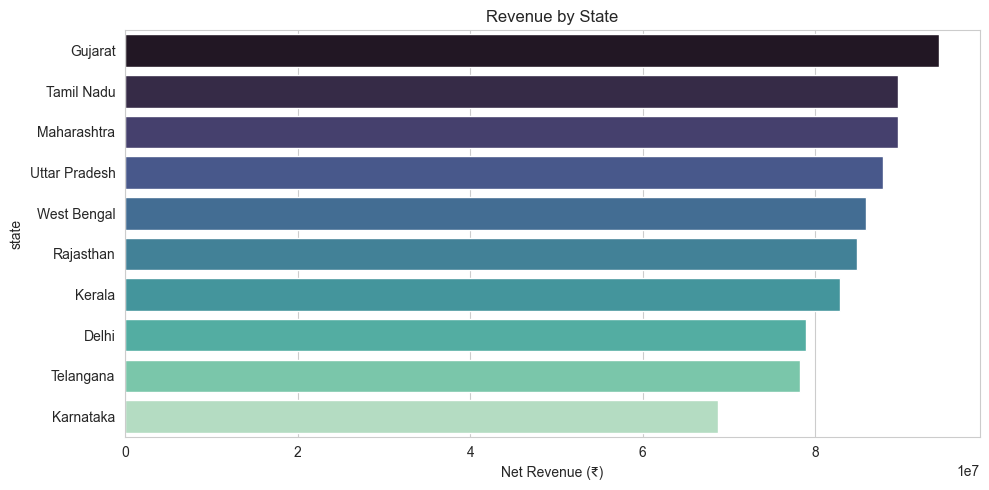

In [16]:
state_revenue = delivered.groupby('state')['net_revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=state_revenue.values, y=state_revenue.index, ax=ax, palette='mako')
ax.set_title('Revenue by State')
ax.set_xlabel('Net Revenue (₹)')
plt.tight_layout()
plt.savefig('../reports/revenue_by_state.png', dpi=120)
plt.show()


## Q4: Which products are performing best?

C:\Users\Srijon\AppData\Local\Temp\ipykernel_12576\49755892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette='flare')


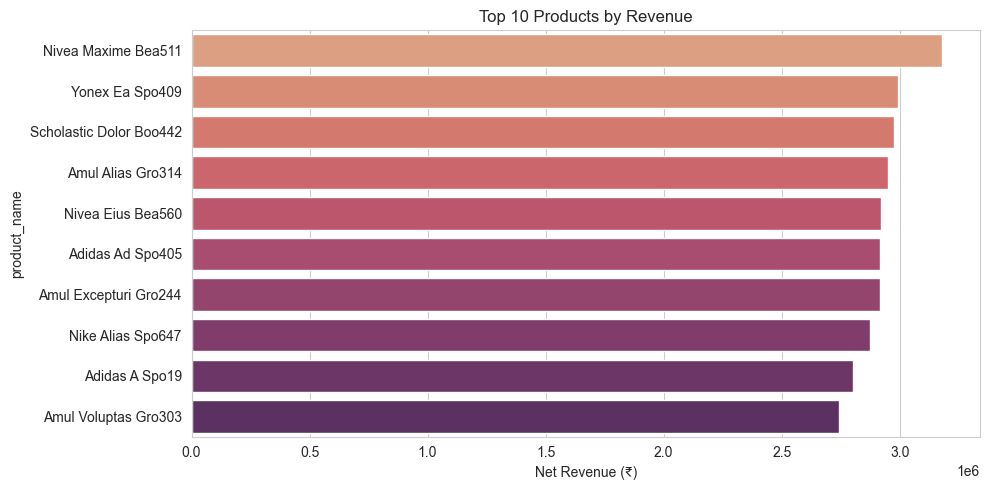

In [17]:
top_products = delivered.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette='flare')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Net Revenue (₹)')
plt.tight_layout()
plt.savefig('../reports/top_10_products.png', dpi=120)
plt.show()


## Q5: Does giving higher discounts actually increase revenue?
This is the most interesting question in the dataset - a genuine
tension between sales volume and profitability.

In [18]:
discount_analysis = delivered.groupby('discount').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('net_revenue', 'sum'),
    total_profit=('profit', 'sum')
)
discount_analysis['profit_margin_pct'] = (discount_analysis['total_profit'] / discount_analysis['total_revenue'] * 100).round(2)
discount_analysis.index = (discount_analysis.index * 100).astype(int).astype(str) + '%'
discount_analysis


,total_quantity,total_revenue,total_profit,profit_margin_pct
discount,,,,
0%,19320,3.495584e+08,1.104106e+08,31.59
5%,6413,1.114214e+08,3.122100e+07,28.02
10%,6225,1.018185e+08,2.471114e+07,24.27
15%,6551,9.980358e+07,1.948998e+07,19.53
20%,6213,8.759038e+07,1.257694e+07,14.36
25%,6627,9.055012e+07,8.103102e+06,8.95


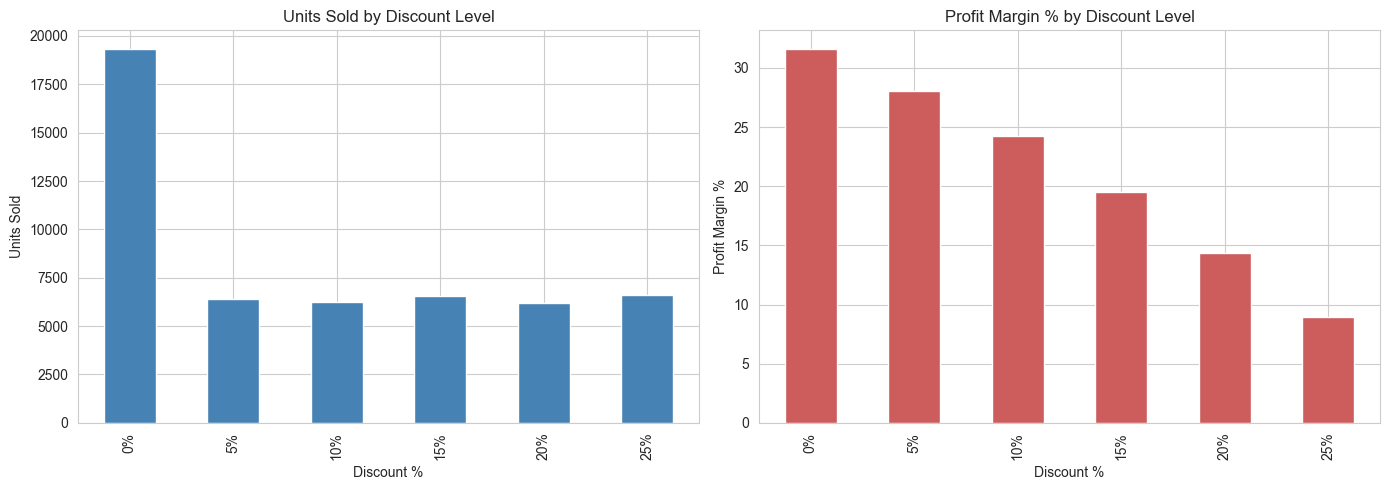

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

discount_analysis['total_quantity'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Units Sold by Discount Level')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Units Sold')

discount_analysis['profit_margin_pct'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Profit Margin % by Discount Level')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Profit Margin %')

plt.tight_layout()
plt.savefig('../reports/discount_vs_margin.png', dpi=120)
plt.show()


## Q6: RFM Customer Segmentation
Recency (days since last order), Frequency (number of orders),
Monetary (total spend) - segmented into actionable customer groups.

In [20]:
snapshot_date = delivered['order_date'].max() + pd.Timedelta(days=1)

rfm = delivered.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('net_revenue', 'sum')
)

rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def segment(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Champions'
    elif row['f_score'] >= 4 and row['m_score'] >= 3:
        return 'Loyal Customers'
    elif row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New Customers'
    elif row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Potential Loyalists'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    elif row['r_score'] <= 2 and row['f_score'] <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(segment, axis=1)
rfm.to_csv('../reports/rfm_segments.csv')
rfm.sort_values('rfm_total', ascending=False).head(10)


,recency,frequency,monetary,r_score,f_score,m_score,rfm_total,segment
customer_id,,,,,,,,
4009,71,7,4.198228e+05,5,5,5,15,Champions
4179,46,37,2.259217e+06,5,5,5,15,Champions
4125,39,12,5.831855e+05,5,5,5,15,Champions
4126,72,6,6.602119e+05,5,5,5,15,Champions
4132,3,16,1.050020e+06,5,5,5,15,Champions
1359,59,12,6.227941e+05,5,5,5,15,Champions
4138,4,10,7.817935e+05,5,5,5,15,Champions
1346,42,6,3.538459e+05,5,5,5,15,Champions
4140,23,11,5.709771e+05,5,5,5,15,Champions


In [21]:
segment_summary = rfm.groupby('segment').agg(
    num_customers=('monetary', 'size'),
    avg_monetary=('monetary', 'mean')
).sort_values('avg_monetary', ascending=False)
segment_summary['pct_of_customers'] = (segment_summary['num_customers'] / len(rfm) * 100).round(1)
segment_summary


,num_customers,avg_monetary,pct_of_customers
segment,,,
Champions,796,616706.238974,22.6
Loyal Customers,558,270289.906115,15.8
Potential Loyalists,425,136652.602766,12.1
At Risk,335,130897.454363,9.5
New Customers,274,81321.457916,7.8
Needs Attention,237,73228.733205,6.7
Lost Customers,898,63983.323760,25.5


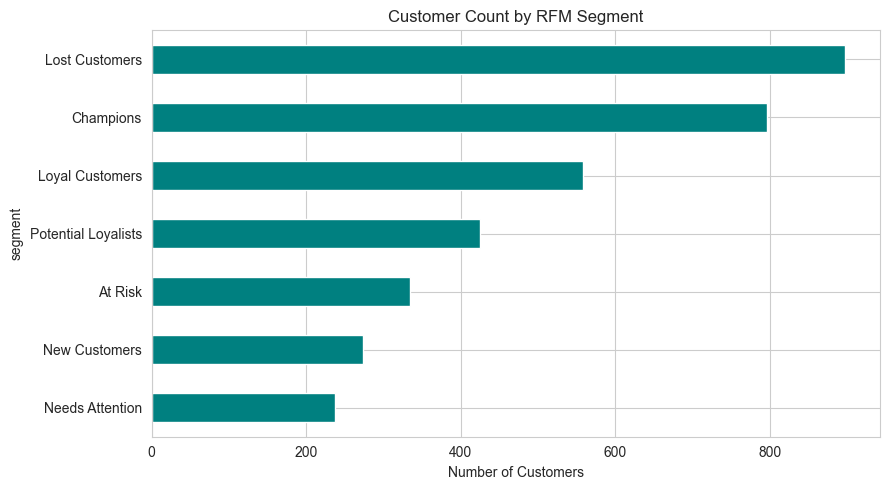

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
segment_summary['num_customers'].sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Customer Count by RFM Segment')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/rfm_segment_counts.png', dpi=120)
plt.show()


## Q7: Pareto check - what share of customers drives most of the revenue?

1,423 customers (40.4% of the customer base) generate roughly 80% of total revenue.


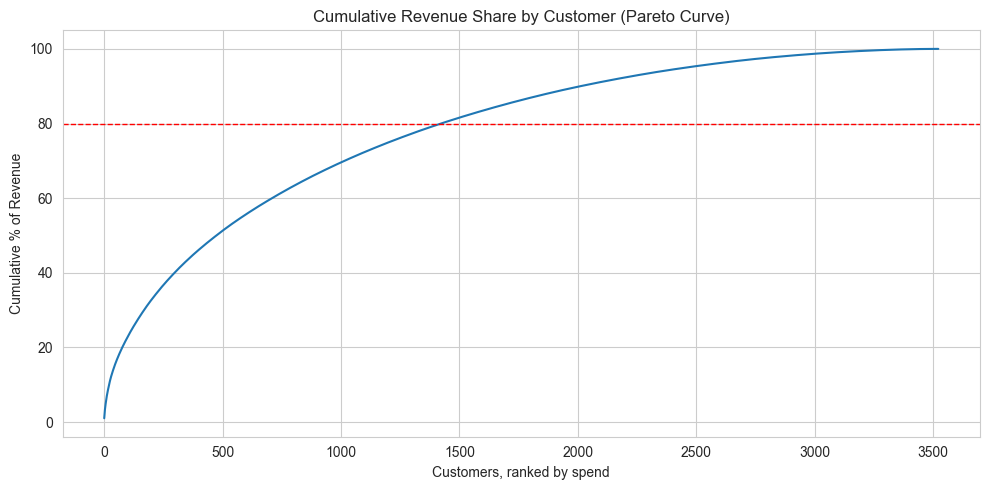

In [23]:
cust_rev = rfm['monetary'].sort_values(ascending=False)
cum_pct = (cust_rev.cumsum() / cust_rev.sum() * 100)
customers_for_80pct = (cum_pct <= 80).sum()
pct_of_base = customers_for_80pct / len(cust_rev) * 100

print(f"{customers_for_80pct:,} customers ({pct_of_base:.1f}% of the customer base) "
      f"generate roughly 80% of total revenue.")

fig, ax = plt.subplots()
cum_pct.reset_index(drop=True).plot(ax=ax)
ax.axhline(80, color='red', linestyle='--', linewidth=1)
ax.set_title('Cumulative Revenue Share by Customer (Pareto Curve)')
ax.set_xlabel('Customers, ranked by spend')
ax.set_ylabel('Cumulative % of Revenue')
plt.tight_layout()
plt.savefig('../reports/pareto_curve.png', dpi=120)
plt.show()
